# 06 — Desbalanceo de clases

El dataset TBX11K tiene un problema de desbalanceo: health y sick tienen 3.800 imágenes cada una, tb solo 800.
Un modelo entrenado sin corrección aprende a ignorar tb porque estadísticamente le conviene.

Este notebook muestra el problema y las dos estrategias principales para corregirlo:

1. **class_weight='balanced'** — ajusta el peso de cada clase durante el entrenamiento
2. **SMOTE** — genera ejemplos sintéticos de la clase minoritaria

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
np.random.seed(42)

---
## 1. El problema

Se carga el CSV de características y se visualiza la distribución real de clases.

In [3]:
import os

# Busca el CSV en la raíz del proyecto (un nivel arriba de notebooks/)
# o en el directorio actual si se corre desde la raíz
for candidate in [
    os.path.join(os.path.dirname(os.getcwd()), 'features_tbx11k.csv'),
    os.path.join(os.getcwd(), 'features_tbx11k.csv'),
    r'c:\Users\estra\Desktop\Tuberculosis\cad-tbx11k\features_tbx11k.csv',
]:
    if os.path.exists(candidate):
        CSV_PATH = candidate
        break
else:
    raise FileNotFoundError('No se encontró features_tbx11k.csv. Corre primero 05_Extraccion_Caracteristicas.ipynb')

df = pd.read_csv(CSV_PATH)

meta_cols = ['image_path', 'class_name', 'label']
feat_cols = [c for c in df.columns if c not in meta_cols]

print(f'CSV cargado: {CSV_PATH}')
print('Distribución de clases:')
print(df['class_name'].value_counts())
print()
print(f'Ratio health/tb : {3800/800:.1f}x')
print(f'Ratio sick/tb   : {3800/800:.1f}x')

CSV cargado: c:\Users\estra\Desktop\Tuberculosis\cad-tbx11k\features_tbx11k.csv
Distribución de clases:
class_name
health    3800
sick      3800
tb         800
Name: count, dtype: int64

Ratio health/tb : 4.8x
Ratio sick/tb   : 4.8x


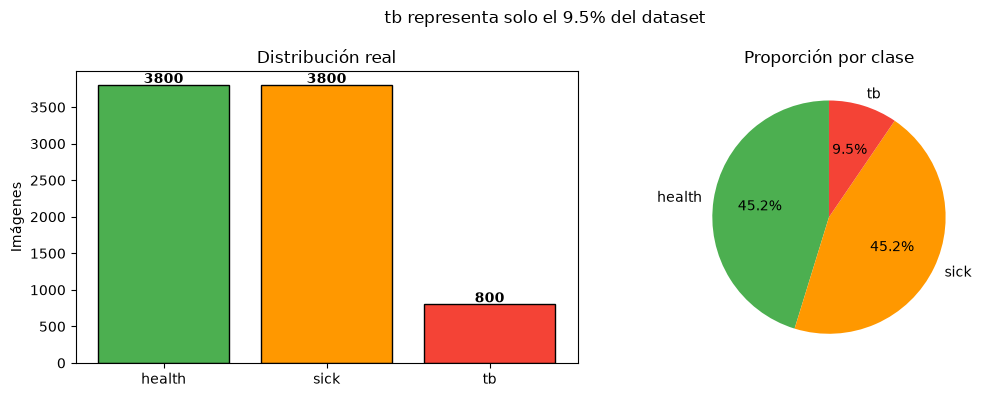

In [4]:
counts = df['class_name'].value_counts()
PALETTE = ['#4CAF50', '#FF9800', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(counts.index, counts.values, color=PALETTE, edgecolor='black')
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, cnt + 30, str(cnt),
                 ha='center', fontweight='bold')
axes[0].set_title('Distribución real')
axes[0].set_ylabel('Imágenes')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=PALETTE, startangle=90)
axes[1].set_title('Proporción por clase')

plt.suptitle('tb representa solo el 9.5% del dataset', fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Qué pasa si no se corrige

Se entrena una regresión logística sin ninguna corrección sobre una muestra pequeña
para ver el efecto del desbalanceo en los resultados.

In [5]:
# Se usa el dataset completo con el desbalanceo real (3800 / 3800 / 800)
cols_demo = [c for c in feat_cols if c.startswith('glcm_') or
             c in ['mean','std','contrast','entropy']]

X = df[cols_demo].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train)} muestras')
print(f'Test : {len(X_test)} muestras')
print(f'Distribución en train: {dict(zip(*np.unique(y_train, return_counts=True)))}')


Train: 5880 muestras
Test : 2520 muestras
Distribución en train: {np.int64(0): np.int64(2660), np.int64(1): np.int64(2660), np.int64(2): np.int64(560)}


In [6]:
modelo_sin = LogisticRegression(max_iter=1000, random_state=42)
modelo_sin.fit(X_train_sc, y_train)
y_pred_sin = modelo_sin.predict(X_test_sc)

print('Sin corrección:')
print(classification_report(y_test, y_pred_sin,
                             target_names=['health','sick','tb'], digits=3))

Sin corrección:
              precision    recall  f1-score   support

      health      0.835     0.921     0.876      1140
        sick      0.876     0.904     0.890      1140
          tb      0.494     0.175     0.258       240

    accuracy                          0.842      2520
   macro avg      0.735     0.667     0.675      2520
weighted avg      0.821     0.842     0.823      2520



---
## 3. Corrección con class_weight='balanced'

class_weight='balanced' hace que sklearn calcule automáticamente
un peso inversamente proporcional a la frecuencia de cada clase:

```
peso_clase = total_muestras / (n_clases × muestras_de_esa_clase)
```

Con eso, cada error en tb penaliza ~5x más que un error en health o sick.
El modelo aprende a prestarle más atención a la clase minoritaria.

In [7]:
modelo_cw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
modelo_cw.fit(X_train_sc, y_train)
y_pred_cw = modelo_cw.predict(X_test_sc)

print('Con class_weight="balanced":')
print(classification_report(y_test, y_pred_cw,
                             target_names=['health','sick','tb'], digits=3))

Con class_weight="balanced":
              precision    recall  f1-score   support

      health      0.888     0.825     0.855      1140
        sick      0.919     0.846     0.881      1140
          tb      0.350     0.600     0.442       240

    accuracy                          0.813      2520
   macro avg      0.719     0.757     0.726      2520
weighted avg      0.851     0.813     0.827      2520



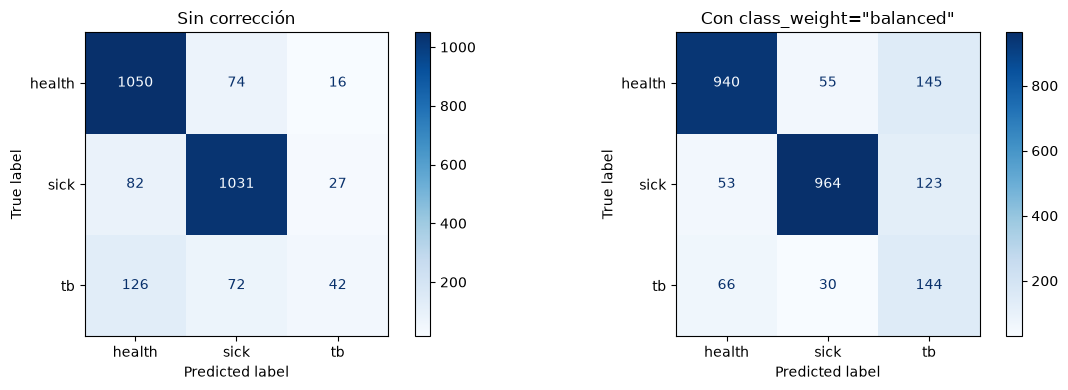

In [8]:
# Matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['health', 'sick', 'tb']

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_sin,
    display_labels=labels,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Sin corrección')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_cw,
    display_labels=labels,
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Con class_weight="balanced"')

plt.tight_layout()
plt.show()

---
## 4. Corrección con SMOTE

SMOTE (Synthetic Minority Oversampling Technique) genera ejemplos sintéticos
de la clase minoritaria interpolando entre ejemplos reales existentes en el
espacio de características.


nuevo_ejemplo = ejemplo_real + λ × (vecino_cercano - ejemplo_real)


donde λ es un número aleatorio entre 0 y 1.

SMOTE se aplica **solo sobre el set de entrenamiento, nunca sobre
el test. Si se aplica sobre el test, los resultados quedan contaminados.

In [9]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print('Distribución ANTES de SMOTE:')
uniq, cnts = np.unique(y_train, return_counts=True)
for u, c in zip(uniq, cnts):
    print(f'  clase {u}: {c}')

print()
print('Distribución DESPUÉS de SMOTE:')
uniq, cnts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(uniq, cnts):
    print(f'  clase {u}: {c}')

Distribución ANTES de SMOTE:
  clase 0: 2660
  clase 1: 2660
  clase 2: 560

Distribución DESPUÉS de SMOTE:
  clase 0: 2660
  clase 1: 2660
  clase 2: 2660


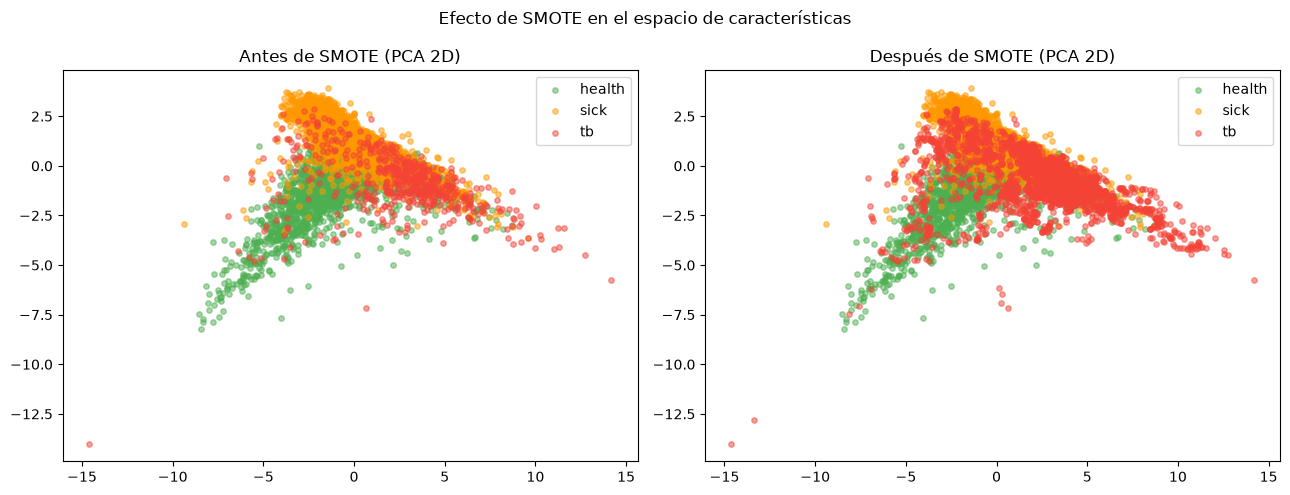

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_orig_2d = pca.fit_transform(X_train_sc)
X_smote_2d = pca.transform(X_train_sm)

colores = {0: '#4CAF50', 1: '#FF9800', 2: '#F44336'}
nombres = {0: 'health', 1: 'sick', 2: 'tb'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for clase in [0, 1, 2]:
    mask = y_train == clase
    axes[0].scatter(X_orig_2d[mask, 0], X_orig_2d[mask, 1],
                    c=colores[clase], label=nombres[clase], alpha=0.5, s=15)
axes[0].set_title('Antes de SMOTE (PCA 2D)')
axes[0].legend()

for clase in [0, 1, 2]:
    mask = y_train_sm == clase
    axes[1].scatter(X_smote_2d[mask, 0], X_smote_2d[mask, 1],
                    c=colores[clase], label=nombres[clase], alpha=0.5, s=15)
axes[1].set_title('Después de SMOTE (PCA 2D)')
axes[1].legend()

plt.suptitle('Efecto de SMOTE en el espacio de características', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
modelo_sm = LogisticRegression(max_iter=1000, random_state=42)
modelo_sm.fit(X_train_sm, y_train_sm)
y_pred_sm = modelo_sm.predict(X_test_sc)

print('Con SMOTE:')
print(classification_report(y_test, y_pred_sm,
                             target_names=['health','sick','tb'], digits=3))

Con SMOTE:
              precision    recall  f1-score   support

      health      0.889     0.832     0.860      1140
        sick      0.916     0.848     0.881      1140
          tb      0.371     0.613     0.462       240

    accuracy                          0.819      2520
   macro avg      0.725     0.764     0.734      2520
weighted avg      0.852     0.819     0.831      2520



---
## 5. Comparativa final

Se compara el recall de tb en los tres escenarios.
El recall de tb es la métrica más importante en este problema clínico:
mide cuántos casos reales de TB detecta el modelo.

In [12]:
from sklearn.metrics import recall_score, f1_score

resultados = pd.DataFrame([
    {
        'Estrategia'  : 'Sin corrección',
        'Recall tb'   : recall_score(y_test, y_pred_sin, labels=[2], average=None)[0],
        'F1 tb'       : f1_score(y_test, y_pred_sin, labels=[2], average=None)[0],
        'Accuracy'    : (y_pred_sin == y_test).mean(),
    },
    {
        'Estrategia'  : 'class_weight balanced',
        'Recall tb'   : recall_score(y_test, y_pred_cw, labels=[2], average=None)[0],
        'F1 tb'       : f1_score(y_test, y_pred_cw, labels=[2], average=None)[0],
        'Accuracy'    : (y_pred_cw == y_test).mean(),
    },
    {
        'Estrategia'  : 'SMOTE',
        'Recall tb'   : recall_score(y_test, y_pred_sm, labels=[2], average=None)[0],
        'F1 tb'       : f1_score(y_test, y_pred_sm, labels=[2], average=None)[0],
        'Accuracy'    : (y_pred_sm == y_test).mean(),
    },
])

print(resultados.round(3).to_string(index=False))
print()
print('El accuracy puede subir o bajar, pero lo que importa es el Recall tb.')
print('Un modelo que no detecta TB tiene recall tb = 0 aunque tenga 90% de accuracy.')

           Estrategia  Recall tb  F1 tb  Accuracy
       Sin corrección      0.175  0.258     0.842
class_weight balanced      0.600  0.442     0.813
                SMOTE      0.612  0.462     0.819

El accuracy puede subir o bajar, pero lo que importa es el Recall tb.
Un modelo que no detecta TB tiene recall tb = 0 aunque tenga 90% de accuracy.


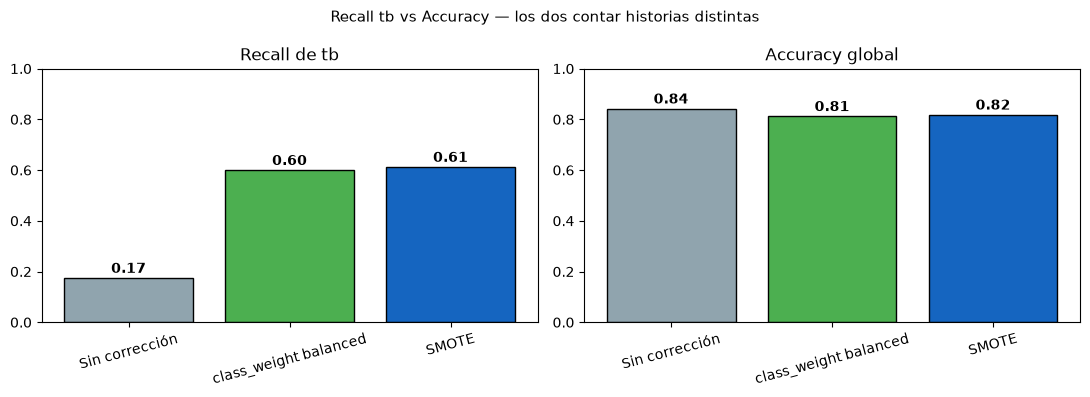

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colores_bar = ['#90A4AE', '#4CAF50', '#1565C0']

axes[0].bar(resultados['Estrategia'], resultados['Recall tb'],
            color=colores_bar, edgecolor='black')
axes[0].set_title('Recall de tb')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(resultados['Recall tb']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

axes[1].bar(resultados['Estrategia'], resultados['Accuracy'],
            color=colores_bar, edgecolor='black')
axes[1].set_title('Accuracy global')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(resultados['Accuracy']):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('Recall tb vs Accuracy — los dos contar historias distintas', fontsize=11)
plt.tight_layout()
plt.show()